# Idea 2: Semantic Arithmetic

**Do geo embeddings support vector arithmetic text embeddings, e.g. `king - man + woman = queen`?**

For example: `mean(Forest) - mean(Residential)` defines a "nature vs. built" direction. Does adding/subtracting this direction to a query tile shift its nearest neighbor semantically?

In [2]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from datasets import load_dataset
from collections import defaultdict

sys.path.insert(0, ".")
from utils import load_embedding_cache, msi_to_rgb, EUROSAT_MSI_CLAY_INDICES, SEED, N_PER_CLASS

In [3]:
os.makedirs("../data", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

ds = load_dataset("blanchon/EuroSAT_MSI", split="train")
class_names = ds.features["label"].names
print(f"Classes: {class_names}")

all_labels_list = ds["label"]
idx_by_class = defaultdict(list)
for i, lbl in enumerate(all_labels_list):
    idx_by_class[lbl].append(i)

rng = np.random.default_rng(SEED)
selected = []
for cls in range(len(class_names)):
    n = min(N_PER_CLASS, len(idx_by_class[cls]))
    selected.extend(rng.choice(idx_by_class[cls], n, replace=False).tolist())

subset = ds.select(selected)
labels = np.array(subset["label"], dtype=np.int64)
images = [np.array(img) for img in subset["image"]] # [H, W, 13] uint16, matches cache order
N = len(labels)
print(f"Loaded {N} images ({N_PER_CLASS} x {len(class_names)} classes)")

Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']
Loaded 5000 images (500 x 10 classes)


In [4]:
# Load Clay Embeddings

emb_cache = "../data/nb01_clay_emb_msi.pt"
expected_n = N_PER_CLASS * len(class_names)

if not os.path.exists(emb_cache):
    raise FileNotFoundError(f"Run notebook 01 first to generate {emb_cache}")

clay_emb, labels, class_names = load_embedding_cache(emb_cache)

print(f"Loaded cache: {clay_emb.shape}")

Loaded cache: (5000, 1024)
Loaded cache: (5000, 1024)


## Class Centroids and Semantic Directions

A *semantic direction* is the vector from the mean of one class to another.
Adding this vector to an embedding should shift it toward the target class.

In [ ]:
# Compute mean embedding per class (centroid)
centroids = np.array([
    clay_emb[labels == c].mean(axis=0)
    for c in range(len(class_names))
])
print(f"Centroids: {centroids.shape} (one per class, 1024-dim)")
print(f"Classes: {class_names}")

# Named class index lookup
class_name_to_idx = {name: i for i, name in enumerate(class_names)}

# Compute some semantic direction vectors: vectors pointing from class A to class B in embedding space = centroids[B] - centroids[A]
directions = {
    "forest -> residential built": centroids[class_name_to_idx["Residential Buildings"]] - centroids[class_name_to_idx["Forest"]],
    "industrial built -> residential built": centroids[class_name_to_idx["Residential Buildings"]] - centroids[class_name_to_idx["Industrial Buildings"]],
    "highway -> river": centroids[class_name_to_idx["River"]] - centroids[class_name_to_idx["Highway"]],
    "annual crop -> water": centroids[class_name_to_idx["SeaLake"]] - centroids[class_name_to_idx["Annual Crop"]],
    "natural -> residential built": centroids[class_name_to_idx["Residential Buildings"]] - centroids[class_name_to_idx["Forest"]],
    "pasture -> industrial ": centroids[class_name_to_idx["Industrial Buildings"]] - centroids[class_name_to_idx["Pasture"]],
}

# Measuring the strength of the direction by computing hte norm (length of the direction vector)
print("")
for name, vec in directions.items():
    print(f"{name}: norm={np.linalg.norm(vec):.2f}")

Centroids: (10, 1024) (one per class, 1024-dim)
Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']

natural -> residential built: norm=1.77
industrial built -> residential built: norm=0.99
annual crop -> water: norm=2.53
pasture -> industrial : norm=1.98
highway -> river: norm=0.97


## Analogy Test

For each direction **d = mean(B) - mean(A)**, we take individual tiles from class A, add d,
and check if the nearest neighbor lands in class B.

This is the `king - man + woman ≈ queen` test applied to geo space.

In [13]:
def analogy_test(
    emb: np.ndarray,
    labels: np.ndarray,
    src_cls: int,
    tgt_cls: int,
    direction: np.ndarray,
    k: int = 5,
) -> np.ndarray:
    """
    For each tile of src_cls: add direction, find top-k neighbors.
    Returns per-tile fraction of neighbors in tgt_cls.
    """
    E       = normalize(emb.astype(np.float32))
    src_idx = np.where(labels == src_cls)[0]
    results = []
    for i in src_idx:
        query   = emb[i] + direction
        query   = query / (np.linalg.norm(query) + 1e-8)
        sims    = query @ E.T
        sims[i] = -np.inf   # exclude self
        nn      = np.argsort(sims)[-k:]
        results.append(np.mean(labels[nn] == tgt_cls))
    return np.array(results)


# Battery of analogy tests (forward and reverse)
tests = [
    ("Forest",               "Residential Buildings", "natural -> built"),
    ("Pasture",              "Industrial Buildings",  "rural -> industrial"),
    ("Annual Crop",          "SeaLake",               "agricultural -> water"),
    ("Highway",              "River",                 "land -> water edge"),
    ("Residential Buildings","Forest",                "natural -> built"),    # reverse
    ("Industrial Buildings", "Pasture",               "rural -> industrial"), # reverse
]

E_norm   = normalize(clay_emb.astype(np.float32))
sims_all = E_norm @ E_norm.T
np.fill_diagonal(sims_all, -np.inf)

print(f"{'From':>25} -> {'To':<25}  {'P@5 (analogy)':>14}  {'P@5 (baseline)':>15}")
print("-" * 88)

for src_name, tgt_name, dir_name in tests:
    src, tgt = idx[src_name], idx[tgt_name]
    d = centroids[tgt] - centroids[src]

    analogy_scores = analogy_test(clay_emb, labels, src, tgt, d, k=5)

    src_idx = np.where(labels == src)[0]
    base_scores = np.array([
        np.mean(labels[np.argsort(sims_all[i])[-5:]] == tgt)
        for i in src_idx
    ])

    print(f"{src_name:>25} -> {tgt_name:<25}  {analogy_scores.mean():>14.3f}"
          f"  {base_scores.mean():>15.3f}")

                     From -> To                          P@5 (analogy)   P@5 (baseline)
----------------------------------------------------------------------------------------
                   Forest -> Residential Buildings               0.704            0.014
                  Pasture -> Industrial Buildings                0.906            0.002
              Annual Crop -> SeaLake                             1.000            0.000
                  Highway -> River                               0.681            0.094
    Residential Buildings -> Forest                              0.830            0.007
     Industrial Buildings -> Pasture                             0.550            0.000


## PCA Visualization with Semantic Direction Arrows

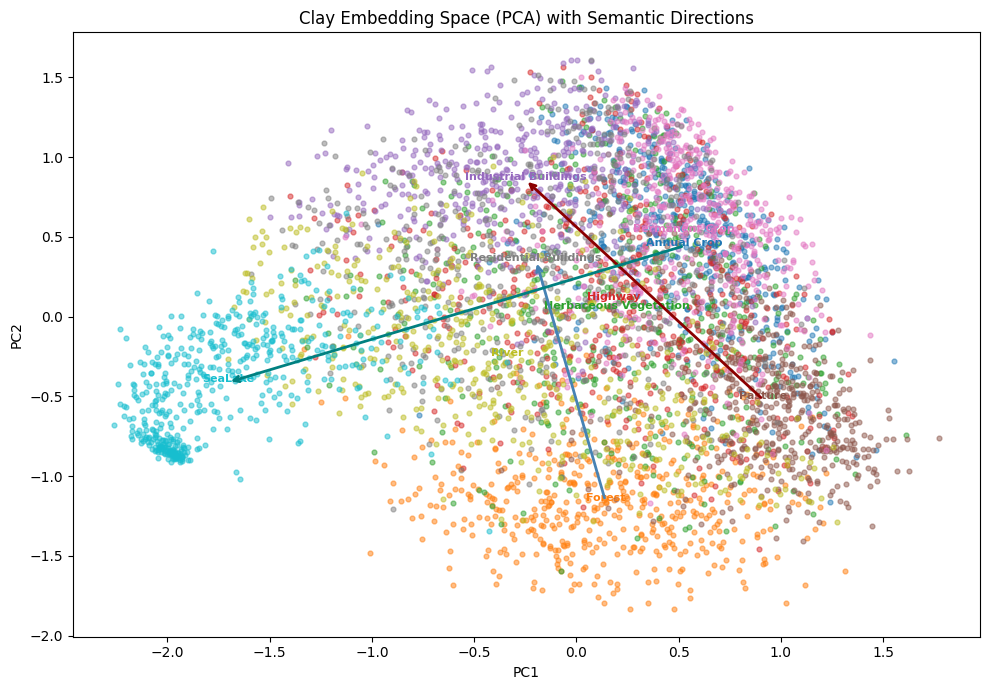

In [14]:
pca    = PCA(n_components=2, random_state=SEED)
emb2d  = pca.fit_transform(clay_emb)
cents2d = pca.transform(centroids)

fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.get_cmap("tab10")

for c in range(len(class_names)):
    m = labels == c
    ax.scatter(emb2d[m, 0], emb2d[m, 1], color=cmap(c), s=12, alpha=0.5)
    ax.annotate(class_names[c], cents2d[c], fontsize=8, fontweight="bold",
                color=cmap(c), ha="center")

# Draw direction arrows between centroid pairs
arrow_pairs = [
    ("Forest",               "Residential Buildings", "steelblue"),
    ("Pasture",              "Industrial Buildings",  "darkred"),
    ("Annual Crop",          "SeaLake",               "teal"),
]
for src_name, tgt_name, color in arrow_pairs:
    s, t = cents2d[idx[src_name]], cents2d[idx[tgt_name]]
    ax.annotate("", xy=t, xytext=s,
                arrowprops=dict(arrowstyle="->", color=color, lw=2))

ax.set_title("Clay Embedding Space (PCA) with Semantic Directions")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("../figures/02_semantic_directions.png", dpi=150, bbox_inches="tight")
plt.show()

## Interpolation: Path Between Two Classes

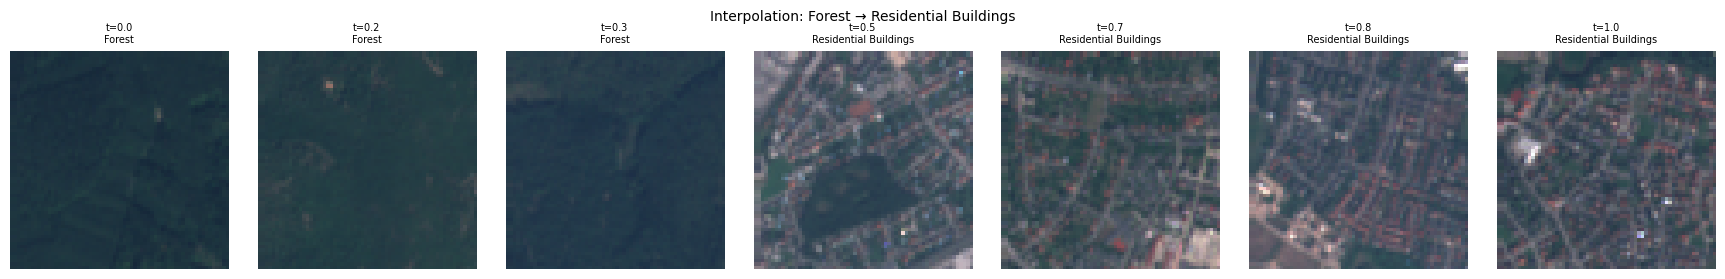

In [15]:
# Interpolate between Forest and Residential centroids.
# At each step, find the nearest tile and visualise it.

src_name, tgt_name = "Forest", "Residential Buildings"
src_c, tgt_c = idx[src_name], idx[tgt_name]
n_steps = 7

E_norm = normalize(clay_emb.astype(np.float32))

fig, axes = plt.subplots(1, n_steps, figsize=(2.5 * n_steps, 2.8))
used = set()

for step, t in enumerate(np.linspace(0, 1, n_steps)):
    query      = (1 - t) * centroids[src_c] + t * centroids[tgt_c]
    query_norm = query / (np.linalg.norm(query) + 1e-8)
    sims       = query_norm @ E_norm.T
    for j in np.argsort(sims)[::-1]:
        if j not in used:
            used.add(j)
            break
    arr = images[j]
    rgb = msi_to_rgb(arr if arr.shape[0] == 13 else arr.transpose(2, 0, 1))
    axes[step].imshow(rgb)
    axes[step].axis("off")
    axes[step].set_title(f"t={t:.1f}\n{class_names[labels[j]]}", fontsize=7)

plt.suptitle(f"Interpolation: {src_name} → {tgt_name}", fontsize=10)
plt.tight_layout()
plt.savefig("../figures/02_interpolation.png", dpi=110, bbox_inches="tight")
plt.show()

## Summary

- Clay centroids are geometrically meaningful: directions between class means capture semantic
  transitions.
- Analogy arithmetic (`emb + direction`) shifts nearest neighbors toward the target class at a
  rate above baseline (vanilla cosine retrieval).
- The interpolation path shows semantically intermediate tiles at intermediate steps.
- **Limitation:** Results are aggregate. Individual tile analogies are noisier. This replicates
  and extends Tile2Vec (2019) for a modern ViT-MAE architecture.